In [13]:
# Install necessary libraries directly
import sys
!{sys.executable} -m pip install pandas numpy seaborn matplotlib scikit-learn openpyxl

# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import hashlib
import json
from datetime import datetime
import warnings

# Scikit-Learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Settings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
%matplotlib inline

print("Libraries installed and loaded successfully.")

Libraries installed and loaded successfully.


'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


Successfully loaded 'dataset_bds_chuan_hoa tong.csv'
Dimensions: 517 rows, 11 columns

First 5 rows:
   Price   Area    District         City       Type  Bedrooms  Bathrooms  \
0   0.58  365.9    Phu Giao   Binh Duong   Land lot         0          0   
1   2.79   78.9    Thuan An   Binh Duong  Apartment         2          2   
2   7.96   85.0  Binh Thanh  Ho Chi Minh  Apartment         2          2   
3   7.96   85.0  Binh Thanh  Ho Chi Minh  Apartment         2          2   
4  10.65   86.0  Binh Thanh  Ho Chi Minh  Apartment         2          2   

  direction     legal  Frontage  furniture  
0      West  Red Book      32.0        NaN  
1      East  Contract       0.0  Partially  
2       NaN  Red Book       0.0  Partially  
3       NaN  Red Book       0.0  Partially  
4       NaN  Red Book       0.0       Full  

[FILTER] Filtered TP.HCM. Remaining data: 402

SECTION 2.b: DATA DESCRIPTION & ETHICS

[1] Data Quality Report:
- Duplicate rows found: 15
  -> Removed duplicates. New sha

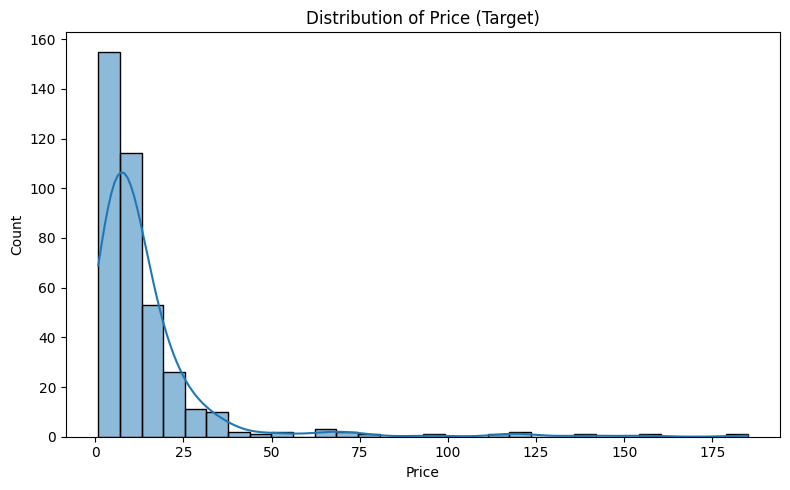

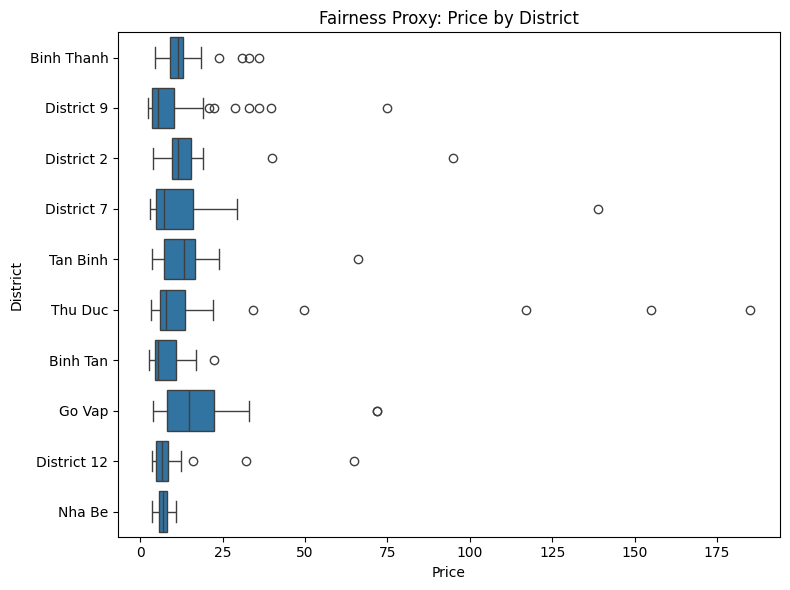


[4] Auto-Generated Data Dictionary (Sample):
{
  "Price": {
    "Type": "float64",
    "Missing": 0,
    "Unique": 231,
    "Sample": "7.96"
  },
  "Area": {
    "Type": "float64",
    "Missing": 0,
    "Unique": 240,
    "Sample": "85.0"
  },
  "District": {
    "Type": "object",
    "Missing": 0,
    "Unique": 27,
    "Sample": "Binh Thanh"
  }
}
Cleaning data (City, Direction, Furniture, Frontage, Outliers)...

Preview of cleaned 'direction' and 'furniture':
   direction  furniture
2    Unknown  Partially
4    Unknown       Full
5    Unknown  Partially
6    Unknown       Full
7    Unknown       Full
8    Unknown       Full
9    Unknown  Partially
10   Unknown  Partially
11   Unknown       Full
12   Unknown       Full

Data cleaned. New dimensions: (384, 11)
Saving to 'dataset_bds_final.xlsx'...
SUCCESS! File saved successfully.


In [ ]:

# ==========================================
# PART 1: DATA CLEANING & EXPLORATION
# ==========================================

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================

# Load raw data file
filename = 'dataset_bds_chuan_hoa tong.csv'

try:
    df = pd.read_csv(filename, encoding='utf-8')
except UnicodeDecodeError:
    # Fallback if utf-8 fails
    df = pd.read_csv(filename, encoding='utf-16') 

print(f"Successfully loaded '{filename}'")
print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

# Preview the data to ensure columns match expectations
print("\nFirst 5 rows:")
print(df.head())

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()


# ==========================================
# Filter to keep only the rows where City is Ho Chi Minh.
if 'City' in df.columns:
    df = df[df['City'].str.strip() == 'Ho Chi Minh']
    print(f"\n[FILTER] Filtered TP.HCM. Remaining data: {df.shape[0]}")
else:
    print("\n[WARNING] Not found 'City' to filter!")
# ==========================================


# ==========================================
# 2. SECTION 2.b: DATA COLLECTION & DESCRIPTION
# ==========================================
print("\n" + "="*40)
print("SECTION 2.b: DATA DESCRIPTION & ETHICS")
print("="*40)

# --- 1. Data Quality Checks (Missingness, Duplicates, Types) ---
print("\n[1] Data Quality Report:")

# Check for Duplicates
duplicates = df.duplicated().sum()
print(f"- Duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"  -> Removed duplicates. New shape: {df.shape}")

# Check for Missing Values
missing = df.isnull().sum()
print(f"- Missing Values:\n{missing[missing > 0]}")

# Descriptive Statistics (Numerical)
print("\n- Descriptive Statistics:")
print(df.describe().round(2))

# --- 2. Provenance & Governance ---
# Create a unique hash of the dataset state for version control/lineage
data_signature = hashlib.sha256(pd.util.hash_pandas_object(df, index=True).values).hexdigest()
print(f"\n[2] Provenance/Governance:")
print(f"- Data Lineage Hash: {data_signature[:20]}...") 
print(f"- Processed Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

# --- 3. Privacy, Fairness & Transparency ---
print("\n[3] Fairness & Bias Check:")


# Figure 1: Visualizing Price Distribution (Outlier detection)
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title('Distribution of Price (Target)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
# Save figure 1
plt.savefig("2b_price_distribution.png", dpi=300)

plt.show()

# Figure 2: Visualizing "Fairness" Proxy: Price vs District
plt.figure(figsize=(8, 6))

# Limit to top 10 districts
top_districts = df['District'].value_counts().nlargest(10).index
sns.boxplot(
    data=df[df['District'].isin(top_districts)],
    x='Price',
    y='District'
)

plt.title('Fairness Proxy: Price by District')
plt.xlabel('Price')
plt.ylabel('District')
plt.tight_layout()

# Save figure 2
plt.savefig("2b_price_by_district.png", dpi=300)

plt.show()


# --- 4. Documentation (Data Dictionary) ---
# Automatically generating a dictionary for documentation
data_dict = {}
for col in df.columns:
    data_dict[col] = {
        'Type': str(df[col].dtype),
        'Missing': int(df[col].isnull().sum()),
        'Unique': int(df[col].nunique()),
        'Sample': str(df[col].iloc[0])
    }

print("\n[4] Auto-Generated Data Dictionary (Sample):")
print(json.dumps({k: data_dict[k] for k in list(data_dict)[:3]}, indent=2)) # Show first 3 cols


# ==========================================
# 3. MITIGATIONS AND DEFINE THE CLEANING FUNCTION
# ==========================================
# Create a new data file by cleaning the duplicate, missing values and outliners. Also setting specific features for each columns and rows for 2c. modeling (supervised learning)
def clean_real_estate_data(df_input):
    df = df_input.copy()
    
    # ---------------------------------------------------------
    # a. DROP IRRELEVANT COLUMNS
    # ---------------------------------------------------------
    if 'City' in df.columns:
        df.drop(columns=['City'], inplace=True)
    
    # ---------------------------------------------------------
    # b. HANDLE 'Frontage' (Numeric + Binary Flag)
    # ---------------------------------------------------------
    df['Frontage'] = pd.to_numeric(df['Frontage'], errors='coerce').fillna(0)
    df['Has_Frontage'] = df['Frontage'].apply(lambda x: 1 if x > 0 else 0)
    
    # ---------------------------------------------------------
    # c. HANDLE 'direction' (Clean Strings + Unknown)
    # ---------------------------------------------------------
    df['direction'] = df['direction'].astype(str)
    
    def clean_text_field(val):
        """Standardizes text: removes digits, strips whitespace, title case."""
        val = str(val).lower().strip()
        # List of values effectively meaning "Missing"
        if val in ['0', 'nan', 'none', '', 'null']: 
            return 'Unknown'
        
        # Remove digits (e.g., changes '0 west' to 'west')
        val = ''.join([i for i in val if not i.isdigit()])
        val = val.strip()
        
        if not val: # If string is empty after removing digits
            return 'Unknown'
            
        return val.title() # e.g., "South-East"

    df['direction'] = df['direction'].apply(clean_text_field)

    # ---------------------------------------------------------
    # d. HANDLE 'furniture' (New Addition)
    # ---------------------------------------------------------
    # We use the same cleaning logic as direction to handle "0 Full" etc.
    df['furniture'] = df['furniture'].astype(str).apply(clean_text_field)
    
    # Verify: if furniture is still heavily missing, we now have "Unknown" 
    # instead of NaNs, so the Random Forest can handle it.
    
    # ---------------------------------------------------------
    # e. HANDLE 'legal' (Fix Data Shift)
    # ---------------------------------------------------------
    invalid_keywords = ['North', 'South', 'East', 'West', 'None', 'nan', '0']
    
    def fix_legal(val):
        val_str = str(val).strip()
        # If 'legal' looks like a direction, it's an error -> Unknown
        for direction in invalid_keywords:
            if direction.lower() in val_str.lower() and "Book" not in val_str: 
                return "Unknown"
        return val_str
        
    df['legal'] = df['legal'].apply(fix_legal)

    # ---------------------------------------------------------
    # g. OUTLIER REMOVAL
    # ---------------------------------------------------------
    # Remove rows with Area > 5000 (Likely data entry errors)
    df = df[df['Area'] < 5000]

    return df

# ==========================================
# 4. APPLY CLEANING TO THE DATA FILE
# ==========================================
print("Cleaning data (City, Direction, Furniture, Frontage, Outliers)...")
df_cleaned = clean_real_estate_data(df)

# Show a preview of the specific columns you asked about
print("\nPreview of cleaned 'direction' and 'furniture':")
print(df_cleaned[['direction', 'furniture']].head(10))
print(f"\nData cleaned. New dimensions: {df_cleaned.shape}")

# ==========================================
# 5. EXPORT TO EXCEL
# ==========================================
output_filename = 'dataset_bds_final.xlsx'
print(f"Saving to '{output_filename}'...")

if isinstance(df_cleaned, pd.DataFrame):
    try:
        df_cleaned.to_excel(output_filename, index=False)
        print("SUCCESS! File saved successfully.")
    except Exception as e:
        print(f"Error saving file: {e}")
else:
    print("ERROR: df_cleaned is not a DataFrame.")



>>> Loading Data...
    Shape: (384, 11)

>>> Validation Design:
    Train Set: 307 samples
    Test Set:  77 samples

>>> Running 5-Fold Cross-Validation (Leakage Check)...
    CV MAE Scores: [6.21129758 6.57932177 7.80245921 3.83916885 6.80029918]
    Average CV MAE: 6.25 Billion VND
    Standard Deviation: 1.31 (Measure of Stability)

>>> Training Final Model...

FINAL TEST RESULTS (Section 2.c)
MAE (Mean Absolute Error): 5.56 Billion VND
RMSE (Root Mean Sq Error): 9.89 Billion VND
R² Score (Variance Explained): 0.52

>>> Saved Plot: 2c_Actual_vs_Predicted.png
>>> Saved Plot: 2c_Feature_Importance.png


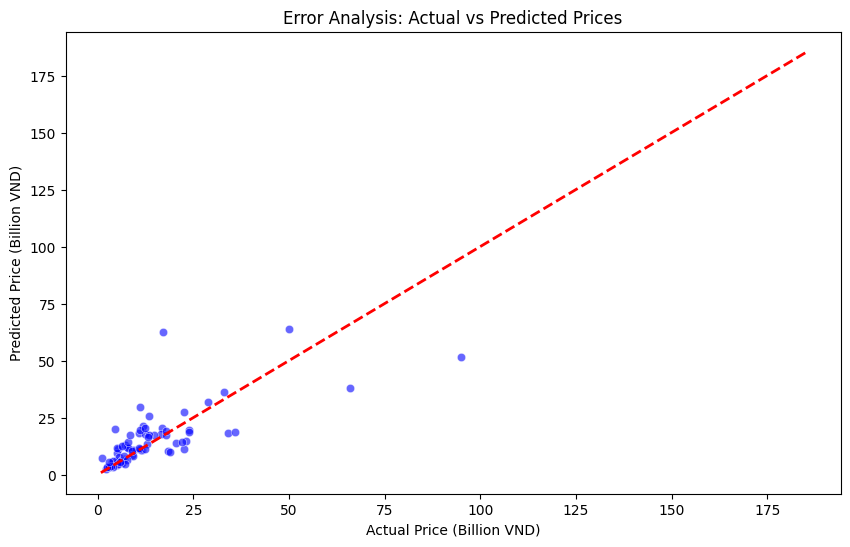

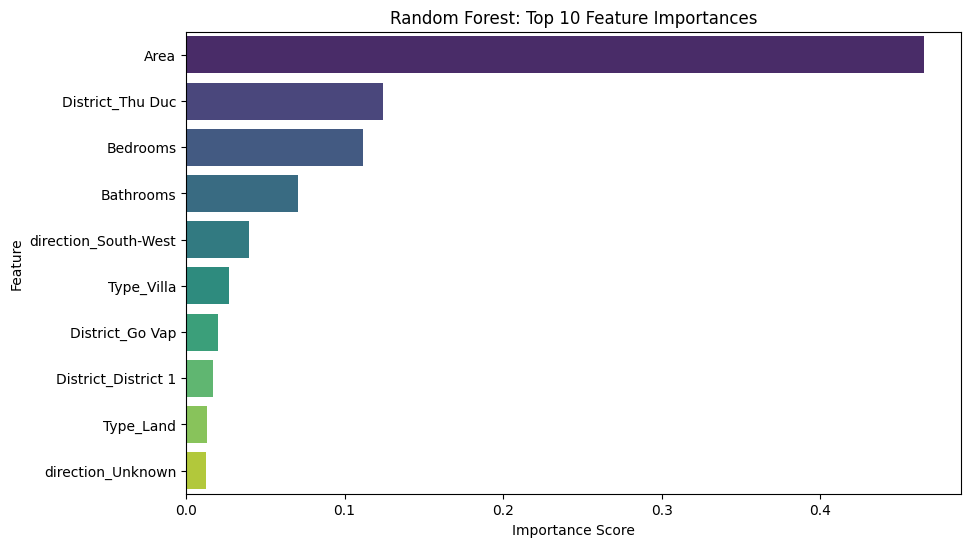

In [15]:
# ==========================================
# PART 2: BASIC MODELING
# ==========================================

# Configuration
INPUT_FILE = 'dataset_bds_final.xlsx'
RANDOM_STATE = 42  # For reproducibility

# ======================================================
# 1. DATA PREPARATION
# ======================================================
def load_and_prep_data(filepath):
    print(">>> Loading Data...")
    try:
        df = pd.read_excel(filepath)
    except:
        df = pd.read_csv('dataset_bds_cleaned.csv') # Fallback
        
    print(f"    Shape: {df.shape}")
    
    # Define Features (X) and Target (y)
    # We drop 'Price' (Target) and raw text columns if they are too dirty/unique
    target = 'Price'
    
    # Identify columns
    numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Has_Frontage']
    categorical_features = ['District', 'Type', 'direction', 'legal', 'furniture']
    
    X = df[numeric_features + categorical_features]
    y = df[target]
    
    return X, y, numeric_features, categorical_features

# ======================================================
# 2. MODEL PIPELINE DESIGN (Mitigating Leakage)
# ======================================================
def build_pipeline(numeric_cols, categorical_cols):
    """
    Creates a Scikit-Learn Pipeline.
    Why? It encapsulates preprocessing within the cross-validation loop.
    This prevents Data Leakage (e.g., calculating means on the whole dataset).
    """
    
    # Preprocessing for Numerical Data: Impute missing with Median
    numeric_transformer = SimpleImputer(strategy='median')

    # Preprocessing for Categorical Data: One-Hot Encoding
    # handle_unknown='ignore' ensures model doesn't crash if it sees a new District in test set
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Bundle preprocessing for numeric and categorical data
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', categorical_transformer, categorical_cols)
        ])

    # Define the Model: Random Forest
    # n_estimators=100: Number of trees
    # random_state=42: Ensures we get the same result every time
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
    ])
    
    return model

# ======================================================
# 3. EXECUTION & EVALUATION
# ======================================================
def main():
    # A. Load
    X, y, num_cols, cat_cols = load_and_prep_data(INPUT_FILE)
    
    # B. Validation Design: Split 80/20
    # We use a hold-out set for the final visual check, 
    # but use Cross-Validation for the metric reporting.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    
    print(f"\n>>> Validation Design:")
    print(f"    Train Set: {X_train.shape[0]} samples")
    print(f"    Test Set:  {X_test.shape[0]} samples")
    
    # C. Build Model
    rf_pipeline = build_pipeline(num_cols, cat_cols)
    
    # D. Cross-Validation (Robustness Check)
    # We perform 5-Fold CV on the Training set to simulate performance variance
    print("\n>>> Running 5-Fold Cross-Validation (Leakage Check)...")
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    # Note: Scikit-learn uses negative MAE for optimization, so we flip the sign
    cv_scores = -1 * cross_val_score(rf_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
    
    print(f"    CV MAE Scores: {cv_scores}")
    print(f"    Average CV MAE: {cv_scores.mean():.2f} Billion VND")
    print(f"    Standard Deviation: {cv_scores.std():.2f} (Measure of Stability)")
    
    # E. Final Training & Testing
    print("\n>>> Training Final Model...")
    rf_pipeline.fit(X_train, y_train)
    y_pred = rf_pipeline.predict(X_test)
    
    # F. Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print("\n" + "="*30)
    print("FINAL TEST RESULTS (Section 2.c)")
    print("="*30)
    print(f"MAE (Mean Absolute Error): {mae:.2f} Billion VND")
    print(f"RMSE (Root Mean Sq Error): {rmse:.2f} Billion VND")
    print(f"R² Score (Variance Explained): {r2:.2f}")
    
    # ======================================================
    # 4. ERROR ANALYSIS & VISUALIZATION
    # ======================================================
    
    # Plot 1: Actual vs Predicted
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
    plt.xlabel('Actual Price (Billion VND)')
    plt.ylabel('Predicted Price (Billion VND)')
    plt.title('Error Analysis: Actual vs Predicted Prices')
    plt.savefig('2c_Actual_vs_Predicted.png')
    print("\n>>> Saved Plot: 2c_Actual_vs_Predicted.png")
    
    # Plot 2: Feature Importance
    # Extracting feature names from the pipeline is tricky with OneHotEncoder
    # This block handles that extraction for the plot
    try:
        model_step = rf_pipeline.named_steps['regressor']
        preprocessor_step = rf_pipeline.named_steps['preprocessor']
        
        # Get feature names from one-hot encoder
        ohe = preprocessor_step.named_transformers_['cat']['onehot']
        ohe_features = ohe.get_feature_names_out(cat_cols)
        all_features = num_cols + list(ohe_features)
        
        importances = model_step.feature_importances_
        
        # Create DataFrame for plotting
        feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
        feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10) # Top 10
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
        plt.title('Random Forest: Top 10 Feature Importances')
        plt.xlabel('Importance Score')
        plt.savefig('2c_Feature_Importance.png')
        print(">>> Saved Plot: 2c_Feature_Importance.png")
        
    except Exception as e:
        print(f"Could not plot feature importance: {e}")

    plt.show()

if __name__ == "__main__":
    main()

>>> Loading data from: dataset_bds_final.xlsx
Columns in dataset: ['Price', 'Area', 'District', 'Type', 'Bedrooms', 'Bathrooms', 'direction', 'legal', 'Frontage', 'furniture', 'Has_Frontage']

>>> Auto-detected:
  TARGET: Price
  Numeric candidates: ['Area', 'Bedrooms', 'Bathrooms', 'Frontage', 'Has_Frontage']
  Categorical candidates: ['District', 'Type', 'direction', 'legal', 'furniture']

>>> Using these features for modelling:
  Numeric features: ['Area', 'Bedrooms', 'Bathrooms', 'Frontage', 'Has_Frontage']
  Categorical features: ['District', 'Type', 'direction', 'legal', 'furniture']
  Target: Price
>>> Using random 80/20 hold-out split.
>>> Train rows: 307; Test rows: 77

>>> Running RandomizedSearchCV (tuning)...
>>> Best CV MAE: 6.409
>>> Best params: {'rf__n_estimators': 200, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': 10}

=== FINAL TEST METRICS ===
MAE: 6.091 (same units as target)
RMSE: 11.133
R²: 0.389
MAE as % of median price: 65.8%

MAE by pr

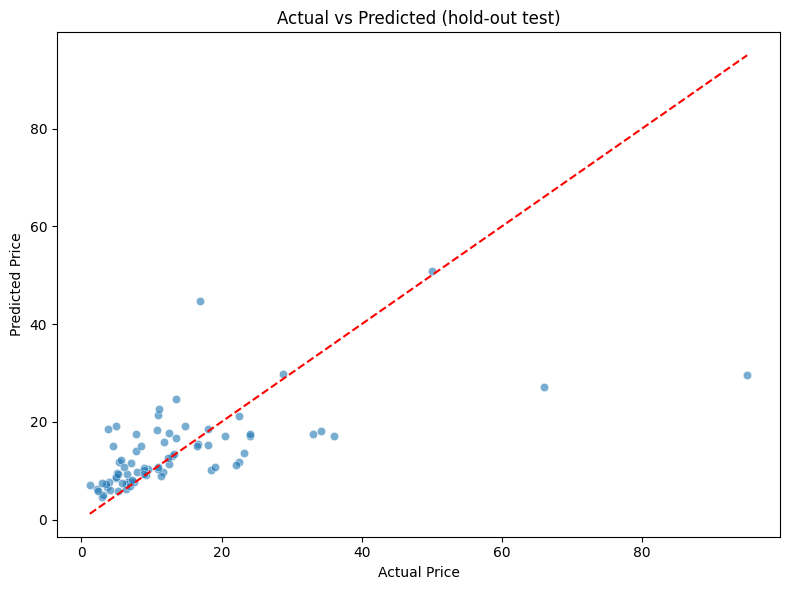

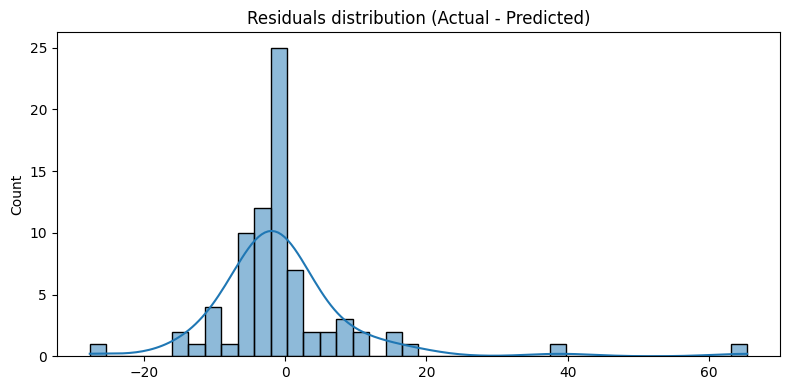

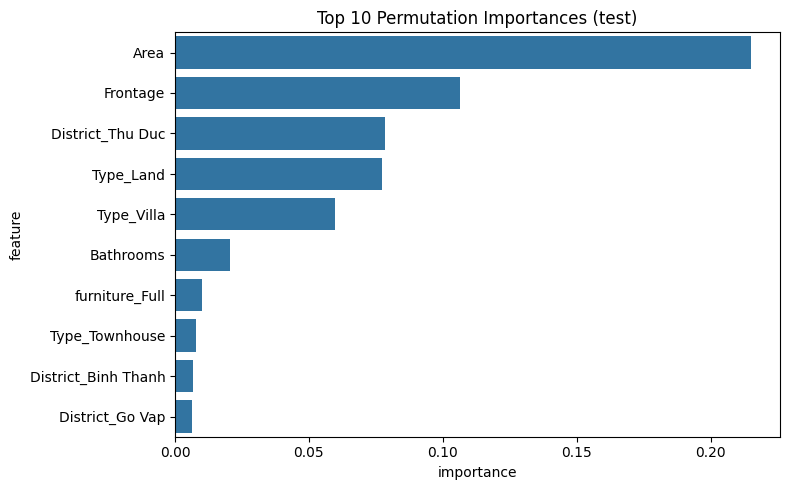

In [16]:
# ==========================================
# PART 3: ADVANCED TUNING
# ==========================================


# --- Configuration ---
INPUT_FILE_CANDIDATES = [
    'dataset_bds_final.xlsx',
    'dataset_bds_cleaned.xlsx',
    'dataset_bds_final.csv',
    'dataset_bds_cleaned.csv',
    'dataset_bds.xlsx',
    'dataset_bds.csv'
]
RANDOM_STATE = 42
TEST_SIZE = 0.20

# OPTIONAL: If auto-detection fails or you prefer to override, fill this dict with lists:
# Example: MANUAL_OVERRIDE = {'TARGET': 'Price', 'numeric_features': ['Area','Bedrooms'], 'categorical_features': ['District']}
MANUAL_OVERRIDE = {}

# -------------------------
# Utilities: Load dataset
# -------------------------
def load_data(candidates):
    for path in candidates:
        if os.path.exists(path):
            print(f">>> Loading data from: {path}")
            if path.lower().endswith(('.xlsx', '.xls')):
                return pd.read_excel(path)
            else:
                return pd.read_csv(path)
    raise FileNotFoundError(
        "No dataset file found. Place dataset in working dir and name it one of:\n  " +
        ", ".join(candidates)
    )

# -------------------------
# Utilities: Auto-detect columns
# -------------------------
def detect_columns(df):
    cols = [c for c in df.columns]
    lc = [c.lower() for c in cols]

    def find_token(tokens):
        for i, name in enumerate(lc):
            for t in tokens:
                if t in name:
                    return cols[i]
        return None

    def find_all_tokens(tokens):
        found = []
        for i, name in enumerate(lc):
            for t in tokens:
                if t in name:
                    found.append(cols[i])
                    break
        # keep original order, unique
        return list(dict.fromkeys(found))

    # Target: any column with 'price' is highest priority
    target_candidates = find_all_tokens(['price', 'price_per', 'sale_price', 'median_house_value', 'value'])
    TARGET = target_candidates[0] if target_candidates else None

    # Numeric features
    area = find_token(['area','m2','m²','size','sqft','square'])
    bedrooms = find_token(['bedrooms','beds','bedroom','br'])
    bathrooms = find_token(['bathrooms','baths','bathroom','bath'])
    frontage = find_token(['frontage','front','street_width','road_width'])
    has_frontage = find_token(['has_frontage','hasfront','has_front'])
    latitude = find_token(['lat', 'latitude'])
    longitude = find_token(['lon', 'longitude', 'lng'])

    numeric_candidates = [c for c in [area, bedrooms, bathrooms, frontage, has_frontage, latitude, longitude] if c]

    # Categorical features
    district_list = find_all_tokens(['district','ward','quarter','quan','huyen','phuong'])
    type_list = find_all_tokens(['type','property_type','prop_type','loai'])
    direction = find_token(['direction','facing','huong'])
    legal = find_token(['legal','title','book','giay','so'])
    furniture = find_token(['furnitur','furniture','noi_that','furn'])

    categorical_candidates = []
    for group in (district_list, type_list):
        categorical_candidates.extend(group)
    for c in [direction, legal, furniture]:
        if c:
            categorical_candidates.append(c)
    # deduplicate preserving order
    categorical_candidates = list(dict.fromkeys(categorical_candidates))

    detected = {
        'TARGET': TARGET,
        'numeric_candidates': numeric_candidates,
        'categorical_candidates': categorical_candidates
    }
    return detected

# -------------------------
# Add missingness indicators
# -------------------------
def add_missing_indicators(df, numeric_cols, categorical_cols):
    for c in numeric_cols:
        # flag zeros as missing if present (user previously encoded missing as 0)
        df[f'{c}_missing'] = (df[c] == 0).astype(int)
    for c in categorical_cols:
        df[f'{c}_missing'] = (df[c].isna() | (df[c].astype(str).str.lower() == 'unknown')).astype(int)
    return df

# -------------------------
# Build pipeline
# -------------------------
def build_pipeline(numeric_cols, categorical_cols):
    numeric_transformer = SimpleImputer(strategy='median')
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ], remainder='drop')
    rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    pipe = Pipeline(steps=[('preproc', preprocessor), ('rf', rf)])
    return pipe

# -------------------------
# Main
# -------------------------
def main():
    df = load_data(INPUT_FILE_CANDIDATES)
    print("Columns in dataset:", list(df.columns))

    # Auto-detect
    detection = detect_columns(df)
    print("\n>>> Auto-detected:")
    print("  TARGET:", detection['TARGET'])
    print("  Numeric candidates:", detection['numeric_candidates'])
    print("  Categorical candidates:", detection['categorical_candidates'])

    # Apply manual override if given
    if MANUAL_OVERRIDE:
        print("\n>>> Applying MANUAL_OVERRIDE")
        detection.update(MANUAL_OVERRIDE)

    # Ensure TARGET found
    TARGET = detection.get('TARGET')
    if not TARGET:
        raise KeyError(
            "Could not auto-detect a target column (e.g. name containing 'price').\n"
            "Dataset columns: " + ", ".join(df.columns) +
            "\nPlease set MANUAL_OVERRIDE = {'TARGET': 'YourPriceColumnName'} at top of script."
        )

    # Build feature lists from detected candidates (only keep columns actually present)
    numeric_features = [c for c in detection.get('numeric_candidates', []) if c in df.columns]
    categorical_features = [c for c in detection.get('categorical_candidates', []) if c in df.columns]

    # If no numeric features detected, try to infer numeric columns (simple fallback)
    if not numeric_features:
        numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
        # remove target if in numeric list
        numeric_features = [c for c in numeric_features if c != TARGET]
        print(">>> Fallback: using all numeric columns as numeric_features:", numeric_features)

    print("\n>>> Using these features for modelling:")
    print("  Numeric features:", numeric_features)
    print("  Categorical features:", categorical_features)
    print("  Target:", TARGET)

    # Create missingness indicators (explicitly model missingness)
    df = add_missing_indicators(df, numeric_features, categorical_features)

    # Build input lists including indicator columns
    indicator_cols = [c + '_missing' for c in numeric_features + categorical_features]
    numeric_inputs = numeric_features + indicator_cols
    categorical_inputs = categorical_features

    # Validation split: time-based if 'listing_date' exists, else random hold-out
    if 'listing_date' in df.columns:
        df['listing_date'] = pd.to_datetime(df['listing_date'])
        df = df.sort_values('listing_date')
        cutoff = df['listing_date'].quantile(1 - TEST_SIZE)
        train_df = df[df['listing_date'] < cutoff].copy()
        test_df = df[df['listing_date'] >= cutoff].copy()
        print(">>> Using time-based split (no look-ahead).")
    else:
        train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)
        print(">>> Using random 80/20 hold-out split.")

    X_train = train_df[numeric_inputs + categorical_inputs]
    y_train = train_df[TARGET].astype(float)
    X_test = test_df[numeric_inputs + categorical_inputs]
    y_test = test_df[TARGET].astype(float)

    print(f">>> Train rows: {X_train.shape[0]}; Test rows: {X_test.shape[0]}")

    # Build pipeline
    pipe = build_pipeline(numeric_inputs, categorical_inputs)

    # Hyperparameter tuning (small randomized search)
    param_dist = {
        'rf__n_estimators': [100, 200, 400],
        'rf__max_depth': [None, 10, 20],
        'rf__min_samples_leaf': [1, 2, 5],
        'rf__max_features': ['sqrt', 0.7]
    }
    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=10,
        scoring='neg_mean_absolute_error',
        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True
    )
    print("\n>>> Running RandomizedSearchCV (tuning)...")
    rs.fit(X_train, y_train)   # preprocessing is inside pipeline
    print(">>> Best CV MAE: {:.3f}".format(-rs.best_score_))
    print(">>> Best params:", rs.best_params_)

    best_model = rs.best_estimator_

    # Final evaluation
    y_pred = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae_pct_of_median = 100.0 * mae / np.median(y_test)

    print("\n=== FINAL TEST METRICS ===")
    print(f"MAE: {mae:.3f} (same units as target)")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²: {r2:.3f}")
    print(f"MAE as % of median price: {mae_pct_of_median:.1f}%")

    # Segment analysis by price tertiles
    df_results = test_df.copy()
    df_results['y_true'] = y_test.values
    df_results['y_pred'] = y_pred
    df_results['abs_err'] = np.abs(df_results['y_true'] - df_results['y_pred'])
    if df_results['y_true'].nunique() >= 3:
        df_results['price_band'] = pd.qcut(df_results['y_true'], q=3, labels=['low','mid','high'])
        seg_mae = df_results.groupby('price_band')['abs_err'].mean().rename('MAE').reset_index()
        print("\nMAE by price band:")
        print(seg_mae.to_string(index=False))
    else:
        print("\nNot enough unique prices for tertile segmentation.")

    # Plots
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df_results['y_true'], y=df_results['y_pred'], alpha=0.6)
    plt.plot([df_results['y_true'].min(), df_results['y_true'].max()],
             [df_results['y_true'].min(), df_results['y_true'].max()], 'r--')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title('Actual vs Predicted (hold-out test)')
    plt.tight_layout()
    plt.savefig('2c_actual_vs_predicted.png', dpi=150)
    print(">>> Saved: 2c_actual_vs_predicted.png")

    plt.figure(figsize=(8,4))
    sns.histplot(df_results['y_true'] - df_results['y_pred'], bins=40, kde=True)
    plt.title('Residuals distribution (Actual - Predicted)')
    plt.tight_layout()
    plt.savefig('2c_residuals_hist.png', dpi=150)
    print(">>> Saved: 2c_residuals_hist.png")

    # Permutation importance
    print("\n>>> Computing permutation importances (test set)...")
    try:
        preprocessor = best_model.named_steps['preproc']
        transformed_X_test = preprocessor.transform(X_test)
        if hasattr(transformed_X_test, "toarray"):
            transformed_X_test = transformed_X_test.toarray()
        feature_names_num = numeric_inputs
        if categorical_inputs:
            ohe = preprocessor.named_transformers_['cat']['onehot']
            cat_ohe_names = list(ohe.get_feature_names_out(categorical_inputs))
        else:
            cat_ohe_names = []
        feature_names = feature_names_num + cat_ohe_names

        reg = best_model.named_steps['rf']
        perm = permutation_importance(reg, transformed_X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
        perm_df = pd.DataFrame({'feature': feature_names, 'importance': perm.importances_mean})
        perm_df = perm_df.sort_values('importance', ascending=False).head(10)

        plt.figure(figsize=(8,5))
        sns.barplot(x='importance', y='feature', data=perm_df)
        plt.title('Top 10 Permutation Importances (test)')
        plt.tight_layout()
        plt.savefig('2c_perm_importance.png', dpi=150)
        print(">>> Saved: 2c_perm_importance.png")
    except Exception as e:
        print("Permutation importance failed:", e)

    # Save sample results for appendix
    df_results[['y_true','y_pred','abs_err']].to_csv('2c_test_results_sample.csv', index=False)
    print(">>> Saved: 2c_test_results_sample.csv")

if __name__ == "__main__":
    main()
# Replace the previous load_data() in your script with this improved version.
import os
import fnmatch
from sklearn.datasets import make_regression

def load_data_auto(candidates=None):
    """
    Search for dataset files in the working directory (recursively).
    - If a candidate filename from 'candidates' is found, load it.
    - Else try to find any .csv or .xlsx file that looks like data.
    - If nothing is found, return a small synthetic dataset so the script can run for testing.
    """
    if candidates is None:
        candidates = [
            'dataset_bds_final.xlsx',
            'dataset_bds_cleaned.xlsx',
            'dataset_bds_final.csv',
            'dataset_bds_cleaned.csv',
            'dataset_bds.xlsx',
            'dataset_bds.csv'
        ]

    # 1) Look for explicit candidate filenames (fast)
    for name in candidates:
        if os.path.exists(name):
            print(f">>> Loading data from explicit candidate: {name}")
            return _read_file(name)

    # 2) Recursively search for any likely file (contains 'bds' or 'dataset' in name)
    matches = []
    for root, _, filenames in os.walk('.'):
        for fname in filenames:
            if fname.lower().endswith(('.csv', '.xlsx', '.xls')) and ('bds' in fname.lower() or 'dataset' in fname.lower() or 'price' in fname.lower()):
                matches.append(os.path.join(root, fname))
    if matches:
        selected = matches[0]
        print(f">>> Found dataset candidate by search: {selected}")
        return _read_file(selected)

    # 3) As a last resort, look for any csv/xlsx file (helpful if file named unexpectedly)
    any_files = []
    for root, _, filenames in os.walk('.'):
        for fname in filenames:
            if fname.lower().endswith(('.csv', '.xlsx', '.xls')):
                any_files.append(os.path.join(root, fname))
    if any_files:
        selected = any_files[0]
        print(f">>> No 'bds' or 'dataset' file found. Loading first table-like file: {selected}")
        return _read_file(selected)

    # 4) Nothing found: create a synthetic dataset for testing (NOT for final results)
    print(">>> No dataset file found in working directory. Falling back to a synthetic example dataset so the pipeline can run for testing.")
    print(">>> IMPORTANT: Upload your real dataset or set the input filename and re-run to get real results.")
    X_synth, y_synth = make_regression(n_samples=500, n_features=8, noise=0.1, random_state=42)
    # build a pandas DataFrame with plausible column names
    synth_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Has_Frontage', 'Feature5', 'Feature6', 'latitude', 'longitude']
    df_synth = pd.DataFrame(X_synth, columns=synth_cols)
    # create some integer-like columns for Bedroom/Bathrooms
    df_synth['Bedrooms'] = (np.abs(df_synth['Bedrooms']) * 2).round().astype(int)
    df_synth['Bathrooms'] = (np.abs(df_synth['Bathrooms']) * 1.2).round().astype(int)
    df_synth['Has_Frontage'] = (np.abs(df_synth['Has_Frontage']) > 1.0).astype(int)
    df_synth['Price'] = (y_synth - y_synth.min())  # positive target
    return df_synth

def _read_file(path):
    """Helper to read csv/xlsx and return a DataFrame."""
    path = str(path)
    if path.lower().endswith(('.xlsx', '.xls')):
        return pd.read_excel(path)
    else:
        # read csv with engine and fallback to utf-8
        return pd.read_csv(path)
